In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۸ — یادگیری مبتنی بر نمونه
## درس ۴: یادگیری وزن‌دار محلی (LWL)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

یادگیری وزن‌دار محلی خانواده‌ای از روش‌هاست که به‌جای مجبورکردن یک مدل سراسری به توضیح همهٔ ناحیه‌های فضای ویژگی، پیرامون هر نقطهٔ پرس‌وجو یک مدل کوچک برازش می‌دهد. رگرسیون خطی سراسری یک خط برای همهٔ مشاهده‌ها می‌کشد. رگرسیون وزن‌دار محلی می‌تواند نزدیک هر پرس‌وجو خط محلی متفاوتی بسازد؛ مشاهده‌های نزدیک را سنگین و مشاهده‌های دور را سبک می‌گیرد. از این رو LWL همراه طبیعی KNN است: هر دو مبتنی بر نمونه‌اند، اما LWL به‌جای رأی کلاس محلی یک مقدار رگرسیون محلی پیش‌بینی می‌کند.

انتخاب‌های اصلی، مدل محلی، فاصله یا kernel تعیین‌کنندهٔ اثر و bandwidth کنترل‌کنندهٔ محلی‌بودن هستند. bandwidth باریک به همسایگی کوچک توجه دارد و خم‌های تند را می‌بیند، اما به نویز حساس است. bandwidth پهن از مشاهده‌های دورتر شواهد می‌گیرد و هموارتر است، اما ممکن است ساختار محلی را نبیند. در این درس ریاضیات را توسعه می‌دهیم، رگرسیون خطی محلی را از ابتدا پیاده‌سازی می‌کنیم، bandwidth را با اعتبارسنجی متقابل انتخاب می‌کنیم و آن را با رگرسیون خطی سراسری و KNN وزن‌دار بر حسب فاصله مقایسه می‌کنیم.

از fish.csv مخزن استفاده می‌کنیم. اگرچه فایل در پوشهٔ Classification است، ستون Weight پیوسته است و برای رگرسیون مناسب است. سطرهای نخست و نوع داده‌ها پیش از مدل‌سازی دیده می‌شوند تا هدف، پیش‌بینی‌کننده‌های عددی و ستون دسته‌ای Species روشن باشند.

In [3]:
def local_linear_predict(x_train, y_train, x_query, bandwidth, ridge=1e-6):
    x_train = np.asarray(x_train, dtype=float).reshape(-1)
    y_train = np.asarray(y_train, dtype=float).reshape(-1)
    x_query = np.asarray(x_query, dtype=float).reshape(-1)
    predictions = []
    for query in x_query:
        weights = np.exp(-0.5 * ((x_train - query) / bandwidth) ** 2)
        design = np.column_stack([np.ones_like(x_train), x_train - query])
        weighted_design = design * weights[:, None]
        system = design.T @ weighted_design + ridge * np.eye(design.shape[1])
        target = design.T @ (weights * y_train)
        coefficients = np.linalg.solve(system, target)
        predictions.append(coefficients[0])
    return np.asarray(predictions)


def local_linear_weights(x_train, query, bandwidth):
    x_train = np.asarray(x_train, dtype=float).reshape(-1)
    return np.exp(-0.5 * ((x_train - query) / bandwidth) ** 2)

### هدف‌های یادگیری

در پایان این درس باید بتوانید:

1. تفاوت LWL با رگرسیون سراسری و رگرسیون KNN را توضیح دهید.
2. وزن‌های kernel گاوسی و پارامتر bandwidth را تعریف کنید.
3. رگرسیون خطی محلی یک‌بعدی را با کمترین مربعات وزن‌دار پیاده‌سازی کنید.
4. bandwidth را با اعتبارسنجی متقابل و بدون نشت اطلاعات مقیاس‌بندی انتخاب کنید.
5. رگرسیون وزن‌دار محلی، خطی سراسری و KNN وزن‌دار بر حسب فاصله را مقایسه کنید.
6. سطرهای آموزش مؤثر بر یک پیش‌بینی پرس‌وجو را بازرسی کنید.
7. ایده را با local ridge regression از یک ویژگی به چند ویژگی استانداردشده گسترش دهید.
8. محدودیت‌های extrapolation، هزینهٔ محاسبه، ناحیه‌های تنک و حساسیت bandwidth را تشخیص دهید.

LWL حتی وقتی کتابخانه آن را مستقیم ارائه نمی‌کند مدل ذهنی مفیدی است. پرسش را از این‌که چه معادلهٔ واحدی همهٔ مشاهده‌ها را برازش می‌دهد به این‌که چه رابطهٔ محلی پیرامون این پرس‌وجوی مشخص پشتیبانی می‌شود تغییر می‌دهد.

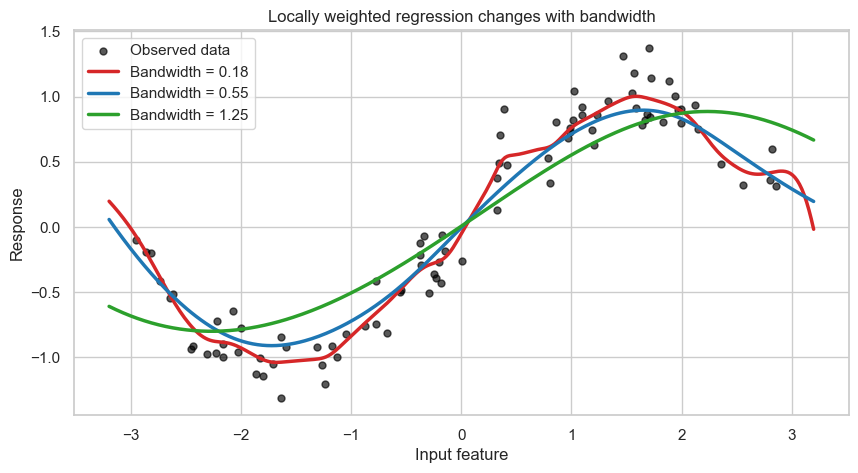

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
synthetic_x = np.sort(rng.uniform(-3, 3, 90))
synthetic_y = np.sin(synthetic_x) + 0.18 * rng.normal(size=synthetic_x.size)
synthetic_grid = np.linspace(-3.2, 3.2, 300)
bandwidths = [0.18, 0.55, 1.25]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(synthetic_x, synthetic_y, s=25, alpha=0.65, color="black", label="Observed data")
for bandwidth, color in zip(bandwidths, ["tab:red", "tab:blue", "tab:green"]):
    curve = local_linear_predict(synthetic_x, synthetic_y, synthetic_grid, bandwidth)
    ax.plot(synthetic_grid, curve, linewidth=2.5, color=color, label=f"Bandwidth = {bandwidth}")
ax.set_xlabel("Input feature")
ax.set_ylabel("Response")
ax.set_title("Locally weighted regression changes with bandwidth")
ax.legend()
plt.show()

## ۱. مدل‌های محلی، kernel و bandwidth

برای پرس‌وجو $x_0$، رگرسیون خطی وزن‌دار محلی ضرایبی را برازش می‌دهد که خطای مربعی وزن‌دار زیر را کمینه کنند:

$$
\hat{\beta}(x_0)=\operatorname*{arg\,min}_{\beta}\sum_{i=1}^{n}w_i(x_0)\left[y_i-\beta_0-\beta_1(x_i-x_0)\right]^2.
$$

عبارت مرکز شدهٔ $x_i-x_0$ باعث می‌شود intercept مستقیماً پیش‌بینی در پرس‌وجو باشد. وزن‌ها معمولاً نزدیک پرس‌وجو بیشترین‌اند. kernel گاوسی انتخاب رایجی است:

$$
w_i(x_0)=\exp\left(-\frac{(x_i-x_0)^2}{2h^2}\right),
$$

که در آن $h$ bandwidth است. $h$ کوچک باعث می‌شود وزن‌ها با رشد فاصله سریع افت کنند. $h$ بزرگ برازش محلی را شبیه رگرسیون گسترده‌تر و سراسری‌تر می‌کند. پیش‌بینی $\hat{y}(x_0)=\hat{\beta}_0(x_0)$ است.

برخلاف رگرسیون معمولی، LWL یک بردار ضرایب دائمی برآورد نمی‌کند. برای هر پرس‌وجو یک مسئلهٔ وزن‌دار تازه حل می‌کند. این انعطاف به آن اجازه می‌دهد رابطه‌های غیرخطی را با خط‌های محلی ساده دنبال کند، اما پیش‌بینی را از نظر محاسباتی گران می‌کند. در کد regularization داریم، زیرا همسایگی بسیار باریک می‌تواند دستگاه خطی وزن‌دار را نزدیک به تکین کند.

In [5]:
fish_path = Path("../../../Datasets/Classification/fish.csv")
fish_df = pd.read_csv(fish_path)
target_column = "Weight"
numeric_features = fish_df.select_dtypes(include="number").columns.drop(target_column).tolist()

display(fish_df.head())
display(fish_df.dtypes.rename("dtype").to_frame())
display(fish_df[numeric_features + [target_column]].describe().T.round(3))
display(fish_df["Species"].value_counts().rename("count").to_frame())

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


,dtype
Species,object
Weight,float64
Length1,float64
Length2,float64
Length3,float64
Height,float64
Width,float64


,count,mean,std,min,25%,50%,75%,max
Length1,159.0,26.247,9.996,7.500,19.050,25.200,32.700,59.000
Length2,159.0,28.416,10.716,8.400,21.000,27.300,35.500,63.400
Length3,159.0,31.227,11.610,8.800,23.150,29.400,39.650,68.000
Height,159.0,8.971,4.286,1.728,5.945,7.786,12.366,18.957
Width,159.0,4.417,1.686,1.048,3.386,4.248,5.584,8.142
Weight,159.0,398.326,357.978,0.000,120.000,273.000,650.000,1650.000


,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6


## ۲. با رابطهٔ غیرخطی مصنوعی آغاز کنید

بهترین راه دیدن bandwidth، مثال غیرخطی کنترل‌شده است. دادهٔ سینوسی نویزی یکسان با سه bandwidth برازش می‌شود. کوچک‌ترین bandwidth می‌تواند جزئیات و نویز را دنبال کند. بزرگ‌ترین مقدار هموار است، اما ممکن است موج را تخت کند. مقدار میانی اغلب میان سازگاری محلی و پایداری تعادل می‌سازد.

این همان مصالحهٔ محلی بایاس-واریانس است. bandwidth نقشی شبیه تعداد همسایه‌ها در KNN دارد. همسایگی کوچک بایاس کم و واریانس زیاد دارد؛ همسایگی گسترده بایاس بیشتر و واریانس کم‌تر. مقدار مناسب باید از دادهٔ آموزش برآورد شود، نه به این دلیل که منحنی در یک نمودار زیبا به نظر می‌رسد انتخاب شود.

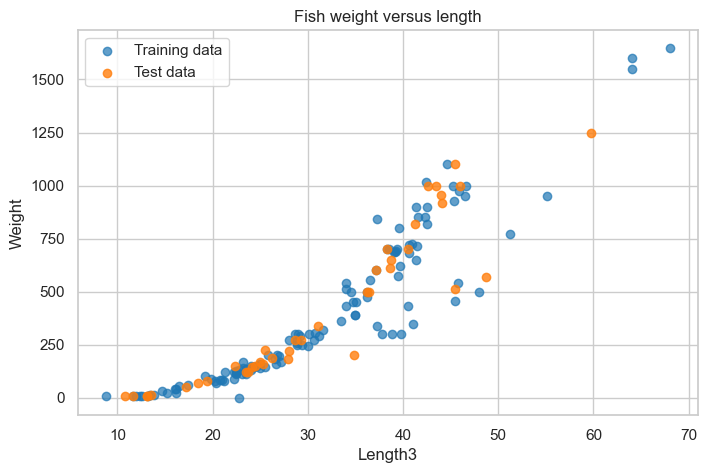

In [6]:
feature_column = "Length3"
fish_X = fish_df[[feature_column]]
fish_y = fish_df[target_column]
X_train, X_test, y_train, y_test = train_test_split(fish_X, fish_y, test_size=0.25, random_state=RANDOM_STATE)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train).ravel()
x_test_scaled = scaler.transform(X_test).ravel()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train[feature_column], y_train, color="tab:blue", alpha=0.7, label="Training data")
ax.scatter(X_test[feature_column], y_test, color="tab:orange", alpha=0.8, label="Test data")
ax.set_xlabel("Length3")
ax.set_ylabel("Weight")
ax.set_title("Fish weight versus length")
ax.legend()
plt.show()

## ۳. fish.csv را بررسی و رگرسیون تک‌ویژگی آماده کنید

دادهٔ fish یک ستون دسته‌ای Species و چند اندازه‌گیری عددی شامل Weight، طول‌ها، Height و Width دارد. با Length3 به‌عنوان پیش‌بینی‌کنندهٔ عددی تفسیرپذیر و Weight به‌عنوان هدف پیوسته آغاز می‌کنیم. این تنظیم ساده اجازه می‌دهد منحنی‌های برازش‌شده را رسم و رفتار محلی را شفاف ببینیم.

طول و وزن واحد و دامنهٔ متفاوتی دارند. Length3 را با آمار مجموعهٔ آموزش استاندارد می‌کنیم. در این صورت bandwidth در واحد ویژگی استاندارد بیان می‌شود، شبکهٔ bandwidth آسان‌تر تفسیر می‌شود و واحدهای خام اندازه‌گیری پنهانی محلی‌بودن را کنترل نمی‌کنند. مجموعهٔ آزمون جدا نگه داشته می‌شود و bandwidth فقط در دادهٔ آموزش انتخاب می‌شود.

,bandwidth,mean_rmse,std_rmse
2,0.3,114.286,32.142
3,0.4,114.807,32.315
4,0.5,115.780,32.643
1,0.2,116.256,31.361
5,0.6,116.842,32.987
6,0.7,118.039,33.160
7,0.8,119.345,33.142
8,0.9,120.663,33.035


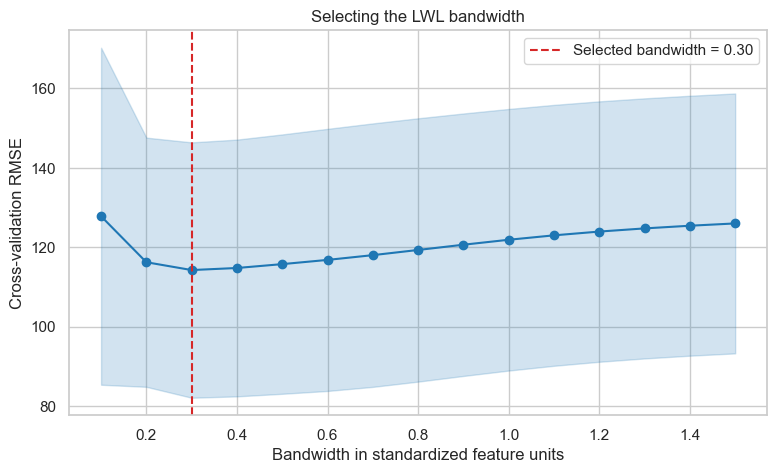

In [7]:
bandwidth_grid = np.linspace(0.10, 1.50, 15)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for bandwidth in bandwidth_grid:
    fold_rmse = []
    for train_index, validation_index in cv.split(X_train):
        fold_scaler = StandardScaler()
        fold_x_train = fold_scaler.fit_transform(X_train.iloc[train_index]).ravel()
        fold_x_validation = fold_scaler.transform(X_train.iloc[validation_index]).ravel()
        fold_prediction = local_linear_predict(fold_x_train, y_train.iloc[train_index].to_numpy(), fold_x_validation, bandwidth)
        fold_rmse.append(np.sqrt(mean_squared_error(y_train.iloc[validation_index], fold_prediction)))
    cv_rows.append({"bandwidth": bandwidth, "mean_rmse": np.mean(fold_rmse), "std_rmse": np.std(fold_rmse)})

bandwidth_results = pd.DataFrame(cv_rows)
best_bandwidth = float(bandwidth_results.loc[bandwidth_results["mean_rmse"].idxmin(), "bandwidth"])
display(bandwidth_results.sort_values("mean_rmse").head(8).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(bandwidth_results["bandwidth"], bandwidth_results["mean_rmse"], marker="o", color="tab:blue")
ax.fill_between(bandwidth_results["bandwidth"], bandwidth_results["mean_rmse"] - bandwidth_results["std_rmse"], bandwidth_results["mean_rmse"] + bandwidth_results["std_rmse"], alpha=0.2, color="tab:blue")
ax.axvline(best_bandwidth, linestyle="--", color="tab:red", label=f"Selected bandwidth = {best_bandwidth:.2f}")
ax.set_xlabel("Bandwidth in standardized feature units")
ax.set_ylabel("Cross-validation RMSE")
ax.set_title("Selecting the LWL bandwidth")
ax.legend()
plt.show()

## ۴. bandwidth را با اعتبارسنجی متقابل انتخاب کنید

Bandwidth یک hyperparameter است. انتخاب آن پس از دیدن خطای آزمون مانند انتخاب K از دقت آزمون، نشت اطلاعات آزمون است. از اعتبارسنجی متقابل پنج‌تایی روی زیرمجموعهٔ آموزش استفاده می‌کنیم. در هر fold، scaler فقط روی مقدارهای آموزش fold برازش می‌شود و مدل محلی مقدارهای اعتبارسنجی را پیش‌بینی می‌کند. RMSE به‌کار می‌رود زیرا وزن ماهی پیوسته است و خطاهای بزرگ باید جریمهٔ بیشتری بگیرند.

منحنی اعتبارسنجی میانگین و انحراف معیار RMSE در foldها را برای هر bandwidth نشان می‌دهد. ناحیهٔ کم و پایدار را شاهدی قوی‌تر از کمینهٔ کوچک و جدا بدانید. bandwidth می‌تواند خیلی کوچک باشد چون دادهٔ محلی مؤثر اندک است و خیلی بزرگ باشد چون تغییرهای غیرخطی را هموار می‌کند. مقدار منتخب بعداً یک‌بار روی آزمون دست‌نخورده استفاده می‌شود.

In [8]:
lwl_test_prediction = local_linear_predict(x_train_scaled, y_train.to_numpy(), x_test_scaled, best_bandwidth)
linear_model = LinearRegression().fit(x_train_scaled.reshape(-1, 1), y_train)
linear_test_prediction = linear_model.predict(x_test_scaled.reshape(-1, 1))
knn_model = KNeighborsRegressor(n_neighbors=9, weights="distance").fit(x_train_scaled.reshape(-1, 1), y_train)
knn_test_prediction = knn_model.predict(x_test_scaled.reshape(-1, 1))

comparison = pd.DataFrame({
    "model": ["Locally weighted linear", "Global linear regression", "Distance-weighted KNN"],
    "MAE": [mean_absolute_error(y_test, lwl_test_prediction), mean_absolute_error(y_test, linear_test_prediction), mean_absolute_error(y_test, knn_test_prediction)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, lwl_test_prediction)), np.sqrt(mean_squared_error(y_test, linear_test_prediction)), np.sqrt(mean_squared_error(y_test, knn_test_prediction))],
    "R2": [r2_score(y_test, lwl_test_prediction), r2_score(y_test, linear_test_prediction), r2_score(y_test, knn_test_prediction)]
})
display(comparison.round(3))

,model,MAE,RMSE,R2
0,Locally weighted linear,67.035,113.232,0.902
1,Global linear regression,110.894,144.148,0.841
2,Distance-weighted KNN,63.299,129.781,0.871


## ۵. رگرسیون محلی، سراسری و مبتنی بر همسایه را مقایسه کنید

رگرسیون خطی وزن‌دار محلی تنها راه مدل‌کردن رابطهٔ خمیده نیست. رگرسیون خطی سراسری یک شیب برای همهٔ ماهی‌ها برآورد می‌کند. KNN وزن‌دار بر حسب فاصله، مقدارهای هدف محلی را بدون برازش شیب محلی میانگین می‌گیرد. LWL میان آن‌هاست: مانند KNN دادهٔ محلی را به‌کار می‌گیرد، اما رابطهٔ خطی محلی برازش می‌دهد و وقتی هدف نزدیک پرس‌وجو نرم تغییر می‌کند می‌تواند بایاس را کم کند.

MAE، RMSE و $R^2$ را روی سطرهای آزمون یکسان مقایسه می‌کنیم. هیچ روشی تضمین‌شده برنده نیست. مقایسه روشن می‌کند هر فرض چه اثری دارد. خط سراسری پایدار و ارزان است، اما شاید خمیدگی را نبیند. KNN ساده و منعطف است، اما برآورد پله‌ای می‌سازد. LWL هموار و سازگار با محل است، اما برای هر پیش‌بینی دستگاه وزن‌دار حل می‌کند.

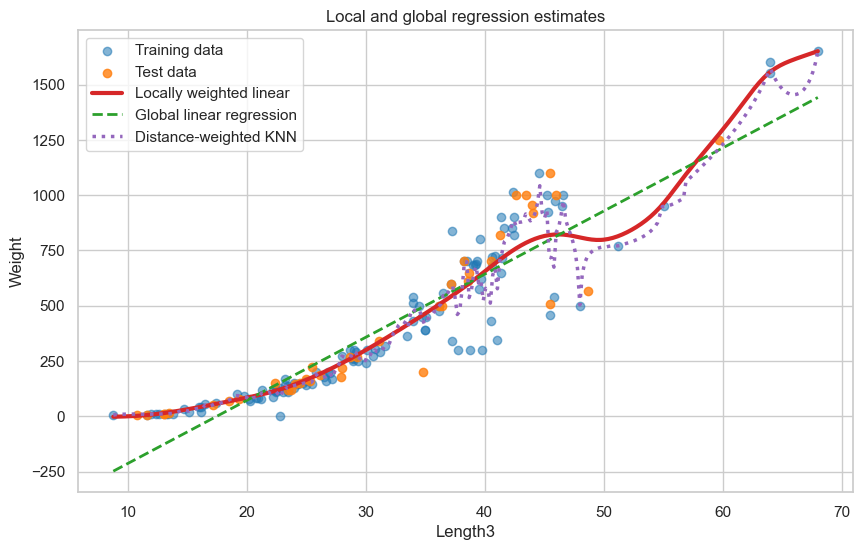

In [9]:
plot_grid_original = np.linspace(fish_X[feature_column].min(), fish_X[feature_column].max(), 300)
plot_grid_scaled = scaler.transform(pd.DataFrame({feature_column: plot_grid_original})).ravel()
lwl_curve = local_linear_predict(x_train_scaled, y_train.to_numpy(), plot_grid_scaled, best_bandwidth)
linear_curve = linear_model.predict(plot_grid_scaled.reshape(-1, 1))
knn_curve = knn_model.predict(plot_grid_scaled.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_train[feature_column], y_train, color="tab:blue", alpha=0.55, label="Training data")
ax.scatter(X_test[feature_column], y_test, color="tab:orange", alpha=0.8, label="Test data")
ax.plot(plot_grid_original, lwl_curve, color="tab:red", linewidth=3, label="Locally weighted linear")
ax.plot(plot_grid_original, linear_curve, color="tab:green", linestyle="--", linewidth=2, label="Global linear regression")
ax.plot(plot_grid_original, knn_curve, color="tab:purple", linestyle=":", linewidth=2.5, label="Distance-weighted KNN")
ax.set_xlabel("Length3")
ax.set_ylabel("Weight")
ax.set_title("Local and global regression estimates")
ax.legend()
plt.show()

## ۶. اثر محلی را برای یک ماهی بررسی کنید

پیش‌بینی یک ماهی پرس‌وجو بر اساس ضریب سراسری ثابت نیست. بر اساس برازش وزن‌دار محلی است، بنابراین وزن‌های kernel نشان می‌دهند کدام سطرهای آموزش بیشترین اهمیت را دارند. سطرهای نزدیک به طول پرس‌وجو وزن گاوسی بالا و سطرهای دور وزن نزدیک صفر می‌گیرند. این موضوع برای اشکال‌زدایی و توضیح یک پیش‌بینی محلی مفید است.

وزن محلی بالا شواهد علّی نیست؛ فقط محاسبهٔ مدل را توصیف می‌کند. با این حال می‌تواند مسئله را آشکار کند: همسایه‌های قوی از ناحیهٔ غیرمنتظره آمده‌اند، پرس‌وجو از همهٔ داده‌های آموزش دور است یا چند سطر نویزی بر برازش bandwidth باریک مسلط‌اند. بازرسی محلی مزیت عملی روش‌های مبتنی بر نمونه است.

,Length3,actual_weight,lwl_prediction
0,19.4,78.0,77.376


,Length3,Weight,kernel_weight,scaled_distance
77,19.2,100.0,0.998,0.017
63,19.8,90.0,0.993,0.035
79,20.2,80.0,0.974,0.069
36,20.3,69.0,0.967,0.078
80,20.8,85.0,0.921,0.122
81,21.0,85.0,0.898,0.139
37,21.2,78.0,0.873,0.156
64,21.3,120.0,0.860,0.165
62,17.4,60.0,0.846,0.174
39,22.2,120.0,0.720,0.243


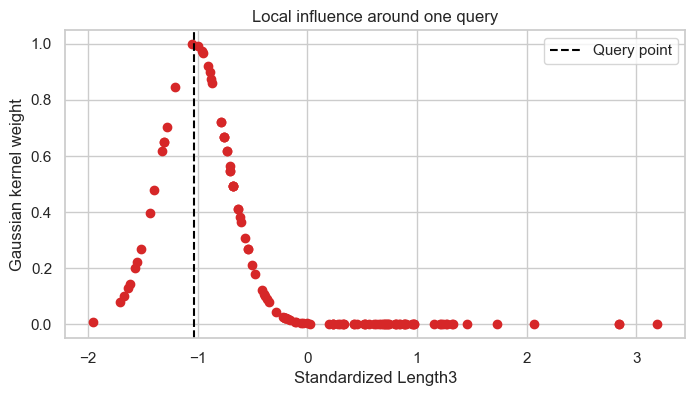

In [10]:
query_index = 0
query_length = float(X_test.iloc[query_index][feature_column])
query_scaled = float(x_test_scaled[query_index])
query_weights = local_linear_weights(x_train_scaled, query_scaled, best_bandwidth)
neighbor_view = X_train.copy()
neighbor_view["Weight"] = y_train
neighbor_view["kernel_weight"] = query_weights
neighbor_view["scaled_distance"] = np.abs(x_train_scaled - query_scaled)

display(pd.DataFrame({feature_column: [query_length], "actual_weight": [y_test.iloc[query_index]], "lwl_prediction": [lwl_test_prediction[query_index]]}).round(3))
display(neighbor_view.sort_values("kernel_weight", ascending=False).head(12).round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_train_scaled, query_weights, color="tab:red")
ax.axvline(query_scaled, color="black", linestyle="--", label="Query point")
ax.set_xlabel("Standardized Length3")
ax.set_ylabel("Gaussian kernel weight")
ax.set_title("Local influence around one query")
ax.legend()
plt.show()

## ۷. از یک ویژگی به چند ویژگی بروید

همین اصل به بیش از یک ویژگی گسترش می‌یابد. برای بردار پرس‌وجوی $x_0$، مدل محلی می‌تواند از ماتریس طراحی وزن‌دار با ویژگی‌های مرکز شده در $x_0$ استفاده کند. kernel می‌تواند فاصلهٔ اقلیدسی در فضای ویژگی استاندارد را به کار برد:

$$
w_i(x_0)=\exp\left(-\frac{\lVert x_i-x_0\rVert_2^2}{2h^2}\right).
$$

مثال بعدی Length3 و Height را به‌کار می‌برد. ridge کوچک دستگاه محلی وزن‌دار را پایدار می‌کند. چند ویژگی وقتی اطلاعات واقعی اضافه کنند پیش‌بینی را بهتر می‌کنند، اما همسایگی محلی را تنک‌تر نیز می‌کنند. هر ویژگی افزوده فاصله را تغییر می‌دهد، پس مقیاس‌بندی، انتخاب ویژگی و اعتبارسنجی مهم‌تر می‌شوند.

In [11]:
two_feature_columns = ["Length3", "Height"]
two_X = fish_df[two_feature_columns]
two_y = fish_df[target_column]
two_X_train, two_X_test, two_y_train, two_y_test = train_test_split(two_X, two_y, test_size=0.25, random_state=RANDOM_STATE)
two_scaler = StandardScaler()
two_train_scaled = two_scaler.fit_transform(two_X_train)
two_test_scaled = two_scaler.transform(two_X_test)

def local_ridge_predict(X_train, y_train, X_query, bandwidth, ridge=1e-4):
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    X_query = np.asarray(X_query, dtype=float)
    predictions = []
    for query in X_query:
        distances = np.linalg.norm(X_train - query, axis=1)
        weights = np.exp(-0.5 * (distances / bandwidth) ** 2)
        design = np.column_stack([np.ones(X_train.shape[0]), X_train - query])
        weighted_design = design * weights[:, None]
        coefficients = np.linalg.solve(design.T @ weighted_design + ridge * np.eye(design.shape[1]), design.T @ (weights * y_train))
        predictions.append(coefficients[0])
    return np.asarray(predictions)

two_prediction = local_ridge_predict(two_train_scaled, two_y_train, two_test_scaled, bandwidth=best_bandwidth)
display(pd.DataFrame({"metric": ["MAE", "RMSE", "R2"], "two_feature_lwl": [mean_absolute_error(two_y_test, two_prediction), np.sqrt(mean_squared_error(two_y_test, two_prediction)), r2_score(two_y_test, two_prediction)]}).round(3))

,metric,two_feature_lwl
0,MAE,31.148
1,RMSE,51.213
2,R2,0.980


## ۸. محدودیت‌های عملی و استفادهٔ مسئولانه

LWL interpolation انجام می‌دهد و بیرون از دامنهٔ ویژگی‌های آموزش reliably extrapolate نمی‌کند. بیرون از بازهٔ آموزش، وزن‌های kernel ممکن است همه بسیار کوچک باشند و خط محلی ناپایدار شود. همچنین نسبت به مدل سراسری در زمان پیش‌بینی گران‌تر است، زیرا برای هر پرس‌وجو مسئلهٔ وزن‌دار حل می‌کند. دادهٔ بزرگ ممکن است به همسایهٔ تقریبی، نمونه‌گیری یا خانوادهٔ مدل دیگری نیاز داشته باشد.

حساسیت bandwidth مرکزی است. bandwidth باریک در ناحیهٔ تنک منحنی نمایشی می‌سازد و به نقطهٔ پرت واکنش افراطی دارد. bandwidth پهن ساختار محلی معنادار را پنهان می‌کند. انتخاب kernel مهم است، اما bandwidth اغلب اثر بزرگ‌تری دارد. نمایش داده از هر دو مهم‌تر است: شناسه، نشت هدف، ویژگی نامرتبط و اندازه‌گیری بدون مقیاس می‌توانند هر فاصلهٔ محلی را گمراه‌کننده کنند.

جریان کاری محتاطانه این است: نوع و دامنهٔ داده را ببینید؛ پیش از برازش تبدیل‌ها داده را تقسیم کنید؛ ورودی عددی را در اعتبارسنجی استاندارد کنید؛ شبکهٔ bandwidth موجه انتخاب کنید؛ پایداری را ارزیابی کنید؛ چند همسایگی محلی را بررسی کنید؛ با baselineهای ساده مقایسه کنید؛ و عملکرد آزمون را فقط پس از کامل‌شدن انتخاب گزارش دهید.

## ۹. تمرین‌ها و جمع‌بندی

1. شبکهٔ bandwidth را تغییر دهید و ببینید ناحیهٔ انتخاب‌شده پایدار می‌ماند یا نه.
2. به‌جای Length3 از Length1 یا Length2 استفاده کنید. منحنی اعتبارسنجی چه تغییری می‌کند؟
3. Width را به‌عنوان ویژگی دوم به مدل local ridge اضافه و معیارهای آزمون را مقایسه کنید.
4. چند ماهی بزرگ را از دادهٔ آموزش حذف و تغییر منحنی محلی و سراسری را بررسی کنید.
5. kernel گاوسی را با kernel فشرده‌ای جایگزین کنید که بیرون از شعاع مشخص وزن صفر می‌دهد.

### جمع‌بندی

یادگیری وزن‌دار محلی نزدیک هر پرس‌وجو مدل می‌سازد، نه یک مدل در همه‌جا. وزن‌های kernel گاوسی اثر محلی را تعریف می‌کنند و bandwidth تعادل میان انعطاف محلی و پایداری هموار را کنترل می‌کند. رگرسیون خطی محلی را پیاده‌سازی کردیم، bandwidth را با اعتبارسنجی بدون نشت انتخاب کردیم، آن را با رگرسیون خطی سراسری و KNN مقایسه کردیم، شواهد پشت یک پیش‌بینی را دیدیم و روش را به دو ویژگی گسترش دادیم. LWL هنگامی قدرتمند است که رابطه‌های محلی در فضای ویژگی تغییر کنند، به شرط آن‌که هندسه، bandwidth و پروتکل اعتبارسنجی آن با دقت انتخاب شوند.